<a href="https://colab.research.google.com/github/rmndrs89/advanced-time-series-prediction/blob/main/2_BaselineModel/OpenCampusAdvancedTimeSeriesPrediction_BaseModel_sktime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detection of Freezing of Gait in Parkinson's Disease


In [3]:
# @title Setup the notebook
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [5]:
!pip install sktime[all_extras] -qq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.3/50.3 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.9/974.9 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 19.6 MB/s eta

In [6]:
DATASET_PATH = Path("/content/drive/MyDrive/Datasets/tdcsfog")
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"

## Get the data

In [7]:
def load_file(file_path: Path) -> tuple[np.ndarray, float]:

    # Load the data into a numpy ndarray
    with open(file_path, "rb") as infile:
        arr = np.load(infile)

    # Extract the accelerometer data as the input features
    features = arr[:, 1:4]

    # Extract the labels
    labels = arr[:, 4:]
    labels = np.max(labels, axis=-1)
    return features, np.any(labels).astype(float)

In [8]:
train_files = [f for f in TRAIN_PATH.iterdir() if f.is_file() and f.suffix == ".npy"]

train_df = {"file_name": [], "label": []}
X_train = np.zeros(shape=(len(train_files), 3, 1280))
y_train = np.zeros(shape=(len(train_files),))
for idx, train_file in enumerate(tqdm(train_files, desc="Processing files")):
    # Get features and corresponding label
    features, label = load_file(train_file)
    X_train[idx, :, :] = features.T  # note we transpote features array
    y_train[idx] = label

    # Bookkeeping
    train_df["file_name"].append(train_file.name)
    train_df["label"].append(label)
train_df = pd.DataFrame(train_df)
if not DATASET_PATH.joinpath("train.csv").exists():
    train_df.to_csv(DATASET_PATH / "train.csv", index=False, header=True)

Processing files: 100%|██████████| 4136/4136 [02:32<00:00, 27.17it/s] 


In [9]:
test_files = [f for f in TEST_PATH.iterdir() if f.is_file() and f.suffix == ".npy"]

test_df = {"file_name": [], "label": []}
X_test = np.zeros(shape=(len(test_files), 3, 1280))
y_test = np.zeros(shape=(len(test_files),))
for idx, test_file in enumerate(tqdm(test_files, desc="Processing files")):
    # Get features and corresponding label
    features, label = load_file(test_file)
    X_test[idx, :, :] = features.T  # note we transpote features array
    y_test[idx] = label

    # Bookkeeping
    test_df["file_name"].append(test_file.name)
    test_df["label"].append(label)
test_df = pd.DataFrame(test_df)
if not DATASET_PATH.joinpath("test.csv").exists():
    test_df.to_csv(DATASET_PATH / "test.csv", index=False, header=True)

Processing files: 100%|██████████| 960/960 [01:01<00:00, 15.58it/s] 


In [10]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((4136, 3, 1280), (4136,), (960, 3, 1280), (960,))

Basic deployment vignette for TSC:

1.   Load training data, `X` in a Panel (more specifically `numpy3D`) format, `y` as 1D `np.ndarray`
2.   Specify the classifier using `sklearn`-like syntax
3.   Fit classifier to training data, `fit(X, y)`
4.   Load new data for prediction.
5.   Predict labels on new data, `predict(X_new)`

## Build models

### Base model: flipping a coin

The most basic idea is to just randomly assign a postive or negative class label to each test instance. This idea resemble flipping a coin and whenever it ends up with heads facing up, we classify the instance as positive.

Alternatively, we can model this by picking a random value from a uniform distribution between 0 and 1. We can then also set a threshold for assign a positive label to a instance, that not necessarily needs to be 0.5.

In [11]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Pick a random number for a uniform distribution between 0 and 1
y_score = np.random.uniform(size=len(y_test))
y_pred = y_score > 0.5
accuracy_score(y_test, y_pred, normalize=True)

0.5

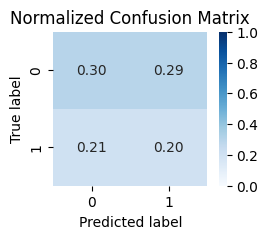

In [12]:
cm = confusion_matrix(y_test, y_pred, normalize="all")

fig, ax = plt.subplots(figsize=(3, 2))
sns.heatmap(cm, annot=True, cmap='Blues', vmin=0, vmax=1, square=True, fmt=".2f", ax=ax)
ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.show()

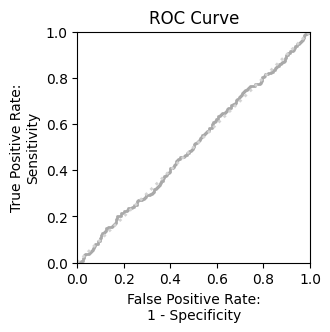

In [13]:
from sklearn.metrics import RocCurveDisplay, roc_curve

fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(fpr, tpr, color="darkgray", lw=2)
ax.plot([0, 1], [0, 1], color="lightgray", lw=2, linestyle=":")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.0])
ax.set_xlabel(f"False Positive Rate:\n1 - Specificity")
ax.set_ylabel(f"True Positive Rate:\nSensitivity")
ax.set_title("ROC Curve")
plt.show()

### Base model: time series forest classifier

In [15]:
from sktime.datatypes._panel._convert import from_3d_numpy_to_nested

X_train_nested = from_3d_numpy_to_nested(X_train, column_names=[f"acc_{x}" for x in "xyz"])
X_test_nested = from_3d_numpy_to_nested(X_test, column_names=[f"acc_{x}" for x in "xyz"])

,acc_x,acc_y,acc_z
0,0 -9.326674 1 -9.860605 2 -10...,0 -2.635752 1 -1.860920 2 -1.13...,0 4.458132 1 4.766235 2 4.55...
1,0 -9.438060 1 -9.109701 2 -8.81...,0 0.284096 1 0.549676 2 0.48...,0 5.100885 1 4.916483 2 4.77...
2,0 -7.874179 1 -7.924927 2 -7.88...,0 -1.948482 1 -1.807054 2 -1.66...,0 5.686514 1 5.757277 2 5.75...
3,0 -9.519624 1 -9.497720 2 -9...,0 -0.813075 1 -0.786539 2 -0.61...,0 0.125249 1 0.066336 2 -0.00...
4,0 -7.834021 1 -7.836625 2 -7.84...,0 -2.794749 1 -2.724067 2 -2.63...,0 3.795588 1 3.751296 2 3.69...
...,...,...,...
4131,0 -9.270367 1 -9.236201 2 -9.17...,0 -0.514210 1 -0.532687 2 -0.52...,0 2.724572 1 2.661332 2 2.71...
4132,0 -9.816607 1 -9.816305 2 -9.83...,0 -0.378156 1 -0.492967 2 -0.58...,0 0.409536 1 0.373685 2 0.37...
4133,0 -9.387065 1 -9.399034 2 -9.39...,0 0.608015 1 0.612547 2 0.61...,0 -1.997188 1 -1.988593 2 -1.98...
4134,0 -9.882233 1 -10.377752 2 -10...,0 -0.591734 1 -0.489334 2 -0.29...,0 1.097360 1 1.371054 2 1.65...


In [29]:
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier
from sktime.classification.interval_based import TimeSeriesForestClassifier
from sktime.dists_kernels.compose_tab_to_panel import FlatDist
from sktime.dists_kernels.indep import IndepDist
from sktime.dists_kernels.scipy_dist import ScipyDist

indep_dist_sum = IndepDist(dist=FlatDist(ScipyDist()), aggfun="sum")
knn_sum = KNeighborsTimeSeriesClassifier(distance=indep_dist_sum)

# Fit the model to the data
knn_sum.fit(X_train, y_train)

# Make predictions on the test set
y_score = knn_sum.predict_proba(X_test)
y_pred = knn_sum.predict(X_test)

In [30]:
accuracy_score(y_test, y_pred)

0.58125

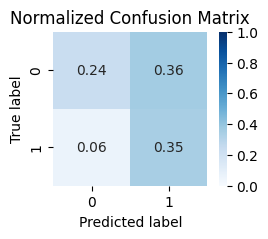

In [33]:
cm = confusion_matrix(y_test, y_pred, normalize="all")

fig, ax = plt.subplots(figsize=(3, 2))
sns.heatmap(cm, annot=True, cmap='Blues', vmin=0, vmax=1, square=True, fmt=".2f", ax=ax)
ax.set_title("Normalized Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.show()